Task 1- Implementation

Step 1 : importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

Step 2: loading the dataset

In [2]:
# loading dataset
df = pd.read_csv('../data/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Step 3 — Select Features

We use:
Annual Income
Spending Score

In [3]:
X = df.iloc[:, [3, 4]].values

Step 4: feature scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Step 5: creating the dendogram

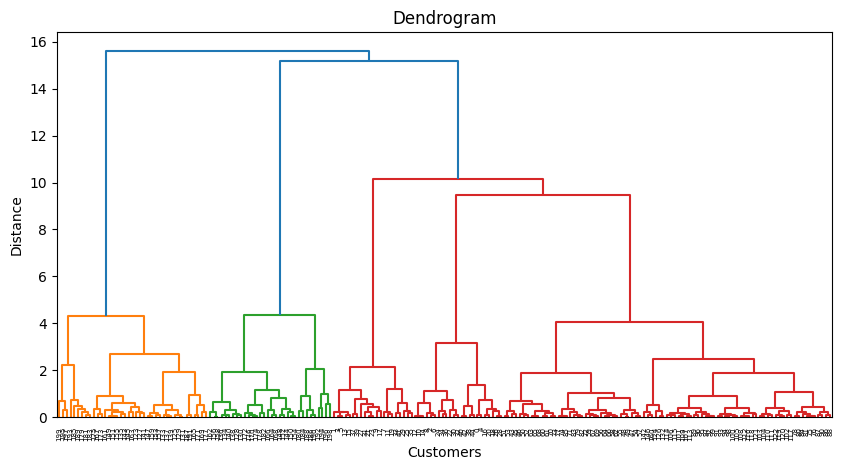

In [5]:
plt.figure(figsize=(10,5))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

Step 6 — Find Optimal Clusters

👉 Look for largest vertical gap in dendrogram
optimal clusters = 5

Step 7 — Apply Agglomerative Clustering

In [6]:
hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

y_hc = hc.fit_predict(X_scaled)

Step 8: visualizinig the clusters

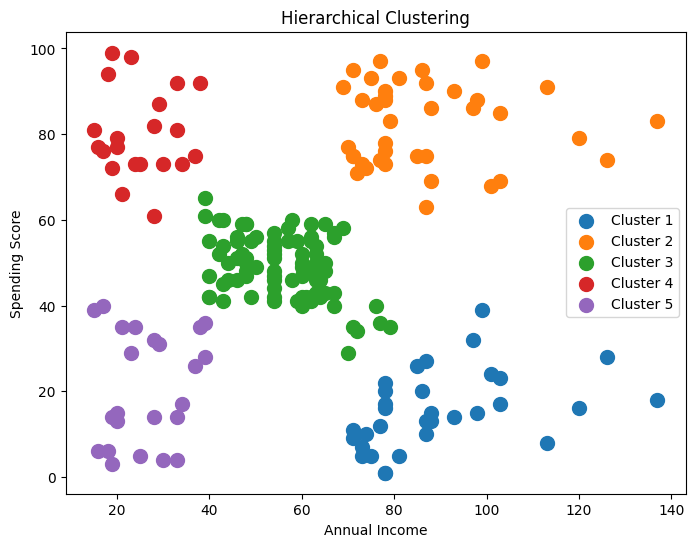

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=100, label='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s=100, label='Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s=100, label='Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s=100, label='Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s=100, label='Cluster 5')

plt.title('Hierarchical Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

✅ Task 2 — Compare with K-Means (IMPORTANT FOR INTERVIEW + PROJECT)

In [8]:
# import metric
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [9]:
#step 2: KMeans model
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [10]:
# Step 3: calculating the Silhoutte Score
kmeans_score = silhouette_score(X_scaled, y_kmeans)
hc_score = silhouette_score(X_scaled, y_hc)

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Clustering Score:", hc_score)

K-Means Silhouette Score: 0.5546571631111091
Hierarchical Clustering Score: 0.5538089226688662


Step 4 — Interpretation

If Silhouette Score is closer to 1 → Better clustering

Comparison:

K-Means → Faster, better for large datasets  
Hierarchical → Better visualization, no need to choose K initially  

Saving the model

In [11]:
import pickle

with open('../models/hierarchical_model.pkl', 'wb') as f:
    pickle.dump(hc, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)